# Why apache_bench evades the VAE — diagnostics, step by step

**Derived from:**
`10_final_deliverables_31_temmuz/06_diagnostics/diagnose_apache_bench.py` and
`test_apache_bench_temporal_hypothesis.py`.

**Model:** clean-only (0% train contamination) VAE,
`phase3_vae/05_contamination_sweep/04_models/contam_0pct` (inference only).

**Data:** `06_attack_type_analysis/test_with_attack_type.csv`, same 18
`_scaled` feature columns as notebooks 1-3.

This notebook imports and re-runs the actual functions from those two
diagnostic scripts (`compare_distributions()`, `plot_top_feature_boxplots()`,
`plot_error_histogram()`, `consecutive_iat()`) rather than copying their
logic, and embeds the scripts' own already-generated PNGs/CSVs alongside the
live re-derivation for the expensive (20-seed) reconstruction-error step.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from IPython.display import Image, display as ipy_display

PROJECT_ROOT = "/Users/mustafa/Desktop/NIDS/IDS-Project"
ATTACK_TYPE_DIR = os.path.join(PROJECT_ROOT, "06_attack_type_analysis")
DIAG_DIR = os.path.join(PROJECT_ROOT, "10_final_deliverables_31_temmuz", "06_diagnostics")
sys.path.insert(0, ATTACK_TYPE_DIR)
sys.path.insert(0, DIAG_DIR)
import evaluate_by_attack_type as single
import diagnose_apache_bench as diag
import test_apache_bench_temporal_hypothesis as temporal

%matplotlib inline
pd.set_option("display.width", 160)
print("Modules loaded:", diag.__file__, temporal.__file__)

Modules loaded: /Users/mustafa/Desktop/NIDS/IDS-Project/10_final_deliverables_31_temmuz/06_diagnostics/diagnose_apache_bench.py /Users/mustafa/Desktop/NIDS/IDS-Project/10_final_deliverables_31_temmuz/06_diagnostics/test_apache_bench_temporal_hypothesis.py


## 1. Feature-level KS test / mean-shift-in-std

Calls `diag.compare_distributions()` directly (the same function `diagnose_apache_bench.py` uses to write `feature_diagnostics_apache_bench.csv`) against a freshly assembled feature frame.

In [2]:
feature_cols = single.load_feature_cols()
df = single.assemble_labeled_features_df(feature_cols)
benign_df = df[df["is_attack"] == 0]
apache_df = df[df["attack_type"] == "apache_bench"]
print(f"benign n={len(benign_df)}, apache_bench n={len(apache_df)}")

apache_diag_live = diag.compare_distributions(feature_cols, benign_df, apache_df)
apache_diag_live["feature_group"] = apache_diag_live["feature"].apply(diag.feature_group)
display(apache_diag_live[["feature", "feature_group", "ks_statistic", "ks_pvalue", "mean_shift_in_benign_std"]])

Loading test_with_attack_type.csv (row_index/window_id/is_attack/attack_type)...
Reconstructing feature columns via row_index against the combined features_all_windows.csv + resampled-window feature tables...
Assembled eval frame: 9931 rows, 18 feature columns.
benign n=6821, apache_bench n=1487


,feature,feature_group,ks_statistic,ks_pvalue,mean_shift_in_benign_std
0,orig_pkts_scaled,packet count/rate,0.755314,1.338918e-321,-0.443859
1,orig_bytes_scaled,byte volume,0.755168,1.343859e-321,-0.391725
2,resp_bytes_scaled,byte volume,0.754435,1.348799e-321,-0.681531
3,resp_pkts_scaled,packet count/rate,0.754435,1.348799e-321,-0.619246
4,duration_scaled,duration,0.692809,1.897212e-321,-0.420031
5,byte_ratio_scaled,byte volume,0.678639,2.020728e-321,-0.370004
6,bytes_per_sec_scaled,byte volume,0.672351,2.075076e-321,-0.243313
7,pkts_per_sec_scaled,packet count/rate,0.622171,3.280596e-321,1.146573
8,service_http,service (one-hot),0.225202,8.424563e-55,0.519096
9,service_none,service (one-hot),0.168026,1.410346e-30,-0.424710


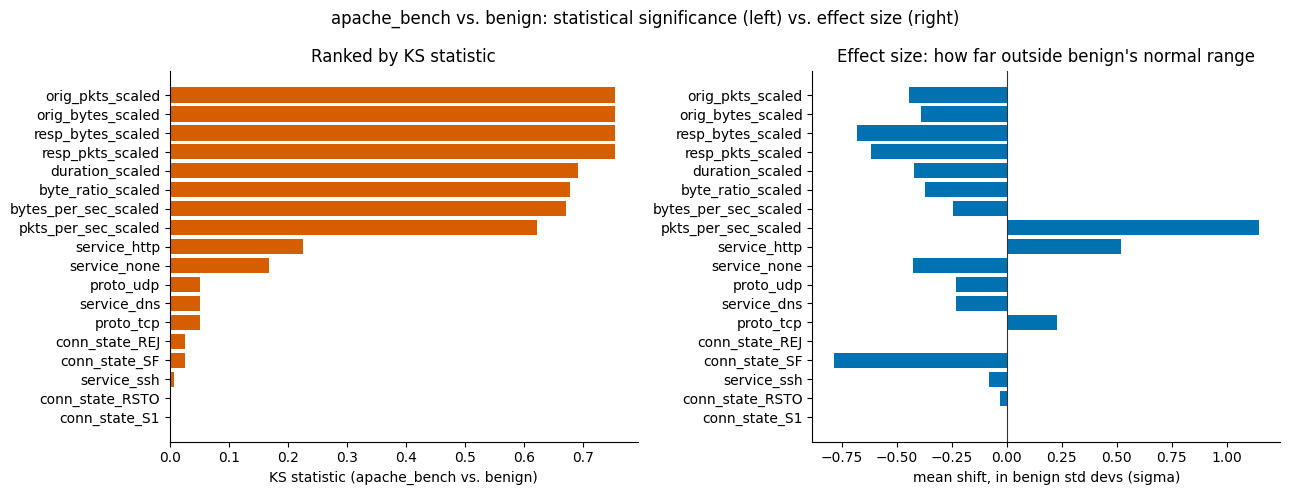

High KS + small sigma shift (top rows on the left, small bars on the right) is exactly the pattern described in diagnose_apache_bench_findings.md section 1: apache_bench forms a narrow cluster INSIDE benign's normal range, not out in its tail.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(apache_diag_live["feature"][::-1], apache_diag_live["ks_statistic"][::-1], color="#D55E00")
axes[0].set_xlabel("KS statistic (apache_bench vs. benign)")
axes[0].set_title("Ranked by KS statistic")
axes[0].spines[["top", "right"]].set_visible(False)

shift = apache_diag_live["mean_shift_in_benign_std"].fillna(0)
axes[1].barh(apache_diag_live["feature"][::-1], shift[::-1], color="#0072B2")
axes[1].axvline(0, color="#333333", linewidth=0.8)
axes[1].set_xlabel("mean shift, in benign std devs (sigma)")
axes[1].set_title("Effect size: how far outside benign's normal range")
axes[1].spines[["top", "right"]].set_visible(False)
fig.suptitle("apache_bench vs. benign: statistical significance (left) vs. effect size (right)")
fig.tight_layout()
plt.show()
print("High KS + small sigma shift (top rows on the left, small bars on the right) is exactly the pattern "
      "described in diagnose_apache_bench_findings.md section 1: apache_bench forms a narrow cluster INSIDE "
      "benign's normal range, not out in its tail.")

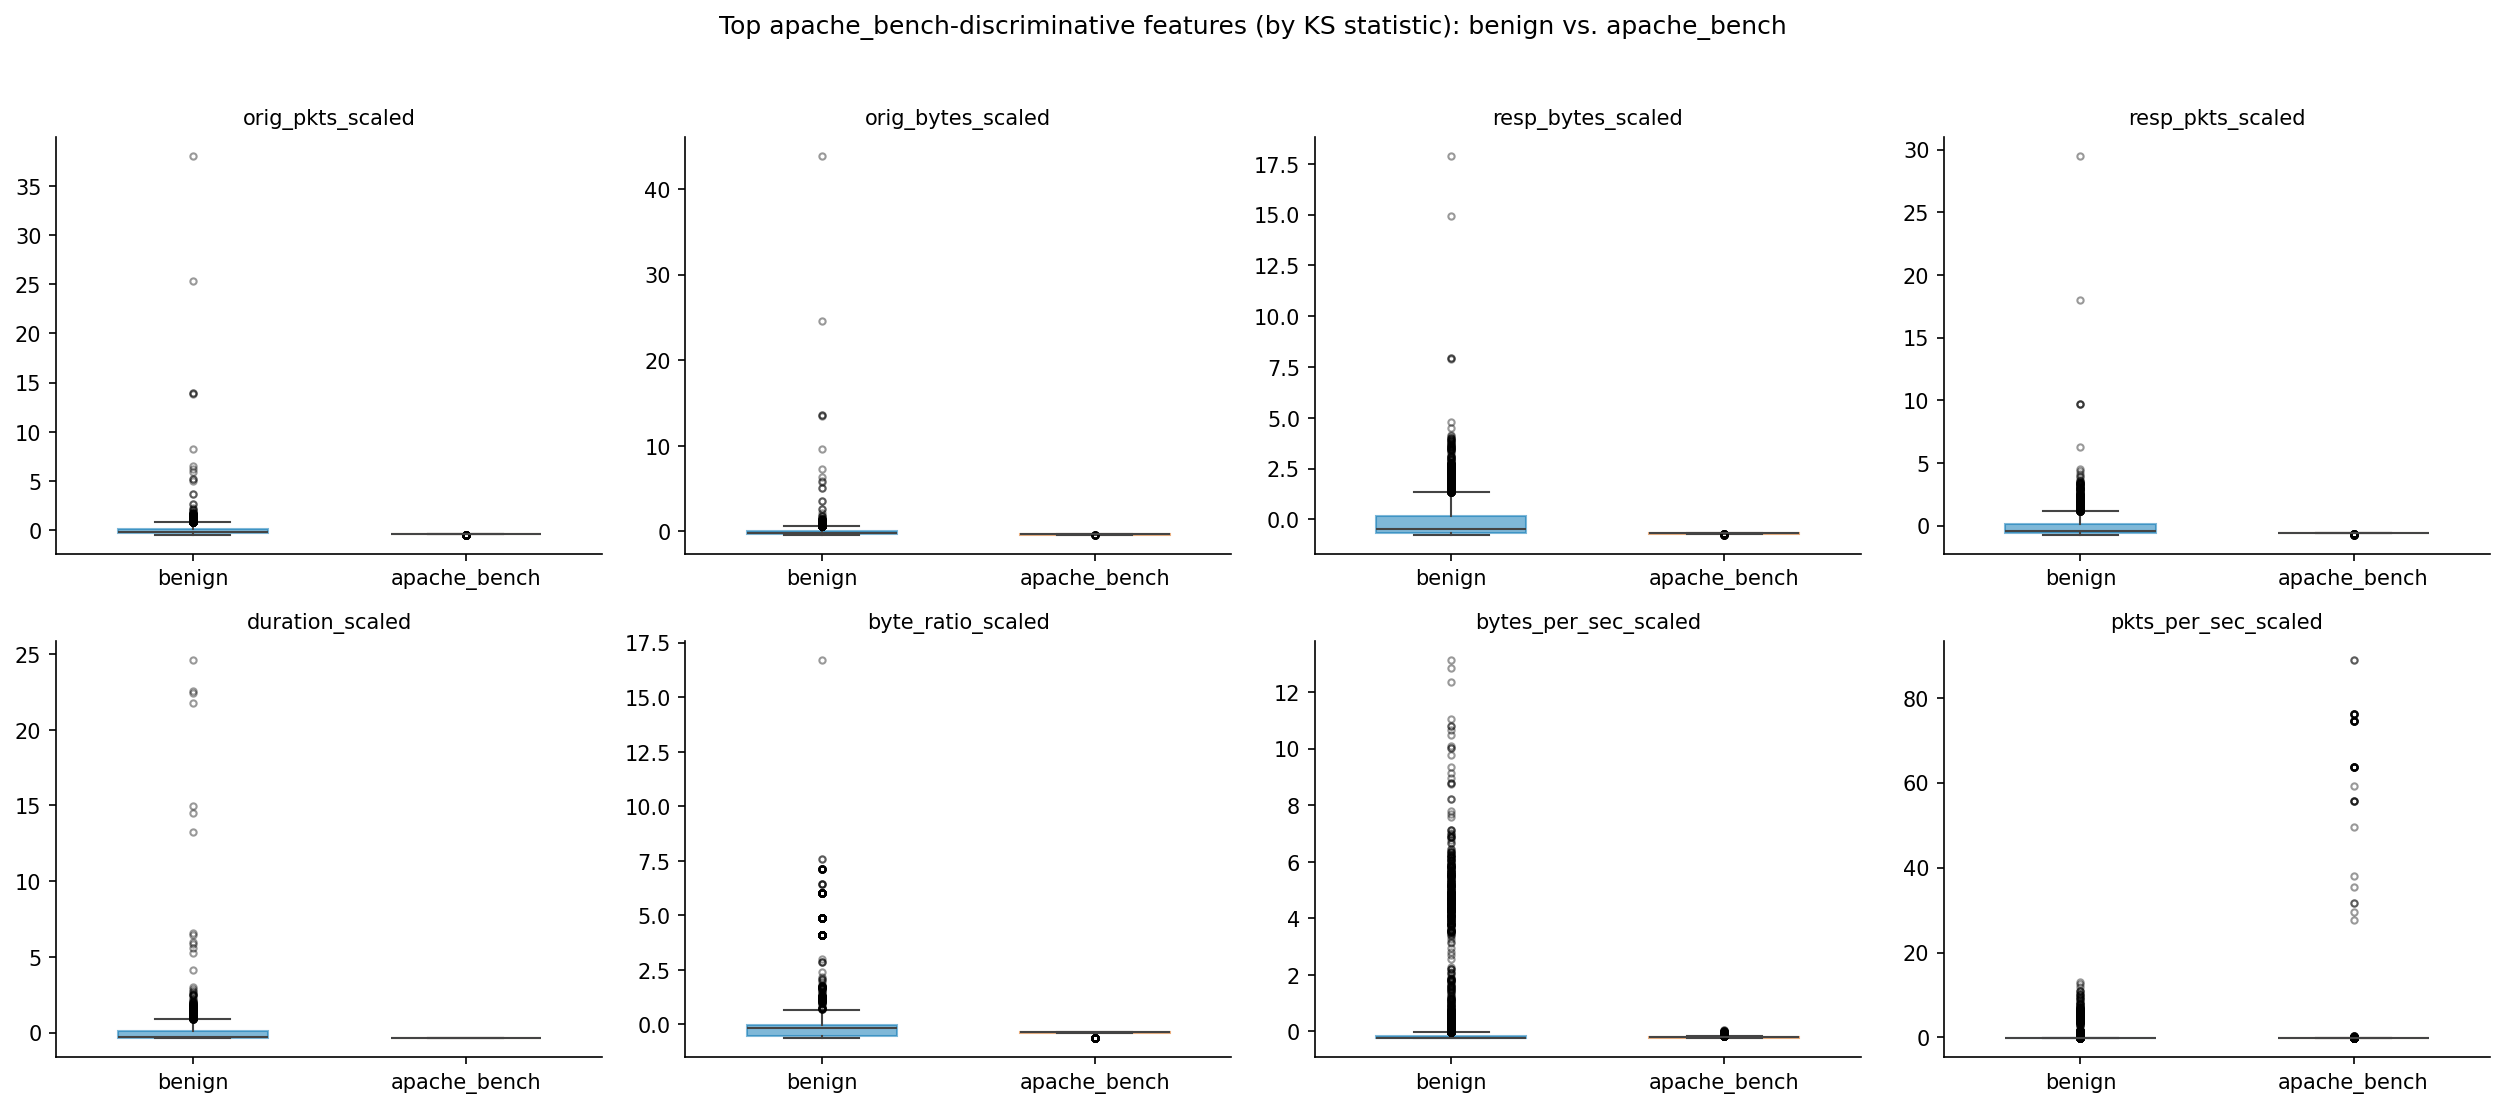

In [4]:
top_features = apache_diag_live["feature"].head(diag.N_TOP_FEATURES).tolist()
_tmp_boxplot_path = os.path.join(DIAG_DIR, "_notebook_tmp_boxplots.png")
diag.plot_top_feature_boxplots(top_features, benign_df, apache_df, _tmp_boxplot_path)
ipy_display(Image(filename=_tmp_boxplot_path))
os.remove(_tmp_boxplot_path)

## 2. VAE reconstruction error histogram (benign / apache_bench / portscan+slowloris)

A **5-seed demo** of `diag.plot_error_histogram()`'s exact log-scale two-panel approach, computed live here (`single.compute_error_matrix()`), followed by the published **20-seed** PNG for the authoritative version (the full VAE ensemble is what `diagnose_apache_bench_findings.md` reports).

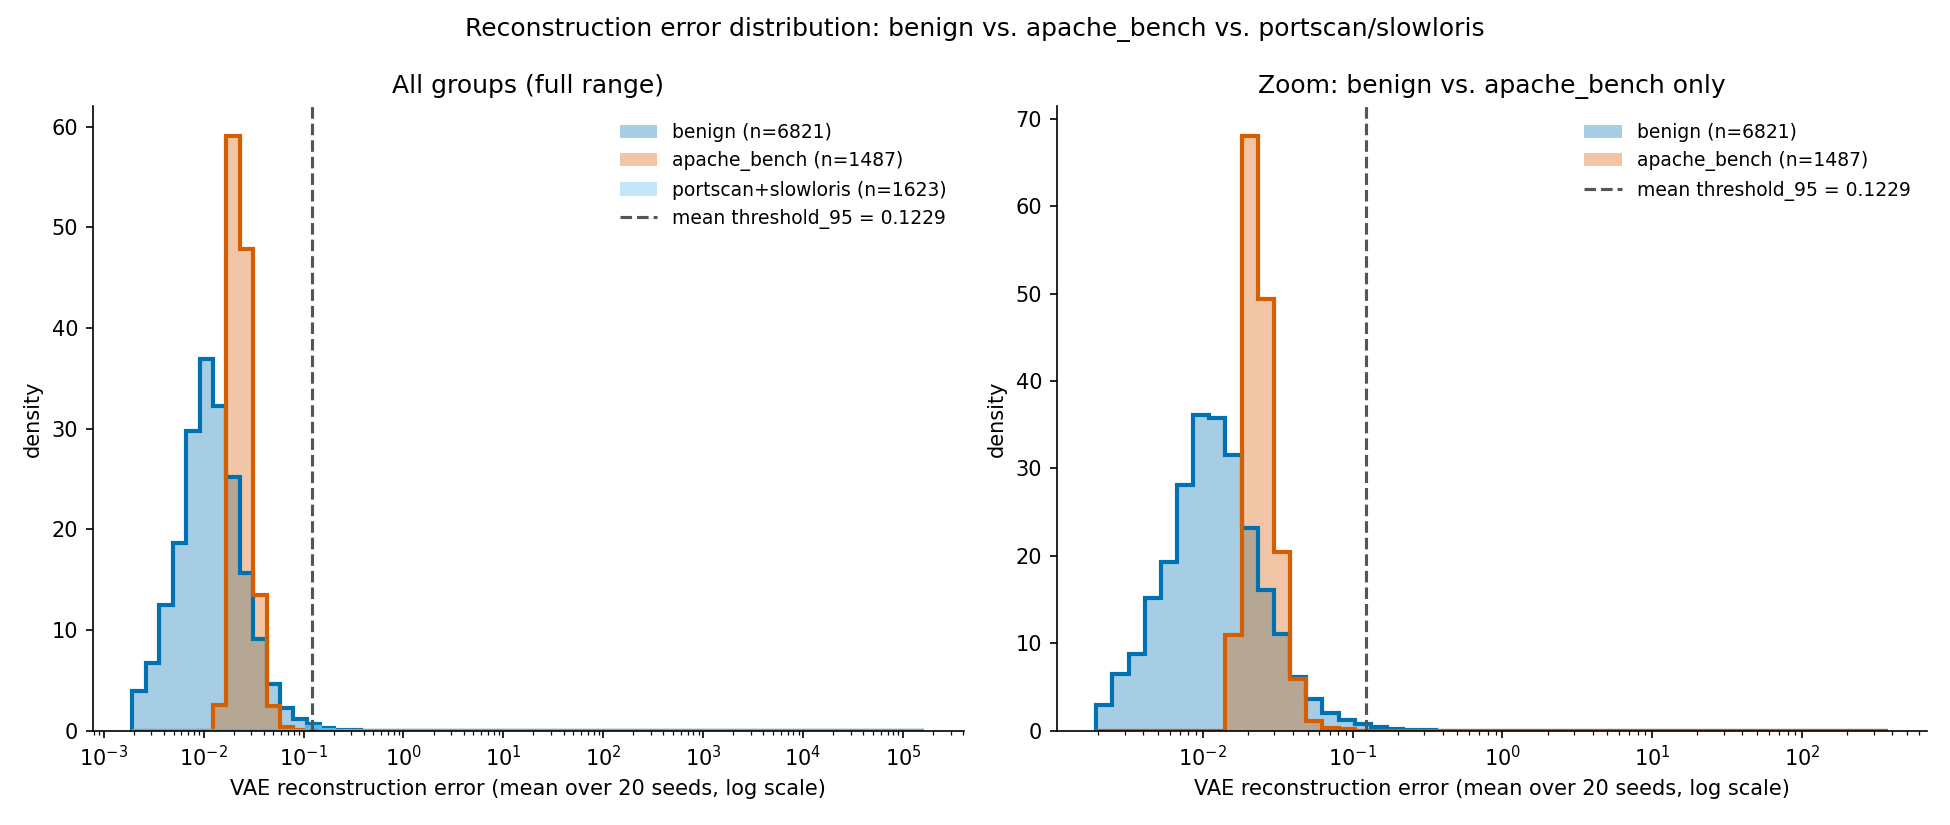

benign: n=6821, mean_error=0.06198, pct_above_demo_thr95=5.03%
apache_bench: n=1487, mean_error=5.408, pct_above_demo_thr95=2.62%
portscan+slowloris: n=1623, mean_error=7.459e+04, pct_above_demo_thr95=99.69%


In [5]:
portscan_df = df[df["attack_type"] == "portscan"]
slowloris_df = df[df["attack_type"] == "slowloris"]
combined = pd.concat([benign_df, apache_df, portscan_df, slowloris_df], ignore_index=True)
X = combined[feature_cols].values.astype("float32")

demo_backend = single.VAEBackend(seeds=list(range(5)))
error_matrix, thresholds = single.compute_error_matrix(X, backend=demo_backend)
mean_errors = error_matrix.mean(axis=0)
mean_threshold = float(np.mean(thresholds))

n_b = len(benign_df)
offsets = {"benign": (0, n_b)}
cursor = n_b
for name, gdf in [("apache_bench", apache_df), ("portscan", portscan_df), ("slowloris", slowloris_df)]:
    offsets[name] = (cursor, cursor + len(gdf)); cursor += len(gdf)

errors_by_group_demo = {
    "benign": mean_errors[offsets["benign"][0]:offsets["benign"][1]],
    "apache_bench": mean_errors[offsets["apache_bench"][0]:offsets["apache_bench"][1]],
    "portscan+slowloris": np.concatenate([
        mean_errors[offsets["portscan"][0]:offsets["portscan"][1]],
        mean_errors[offsets["slowloris"][0]:offsets["slowloris"][1]],
    ]),
}
_tmp_hist_path = os.path.join(DIAG_DIR, "_notebook_tmp_hist.png")
diag.plot_error_histogram(errors_by_group_demo, mean_threshold, _tmp_hist_path)
ipy_display(Image(filename=_tmp_hist_path))
os.remove(_tmp_hist_path)

for name, errs in errors_by_group_demo.items():
    print(f"{name}: n={len(errs)}, mean_error={errs.mean():.4g}, pct_above_demo_thr95={float((errs>mean_threshold).mean()):.2%}")

Published (20-seed) reconstruction error summary:


,group,n,mean_error,std_error,pct_above_mean_threshold95
0,benign,6821,0.060531,0.659163,0.045741
1,apache_bench,1487,5.746087,37.880263,0.026227
2,portscan+slowloris,1623,56906.236413,50282.266374,1.000000


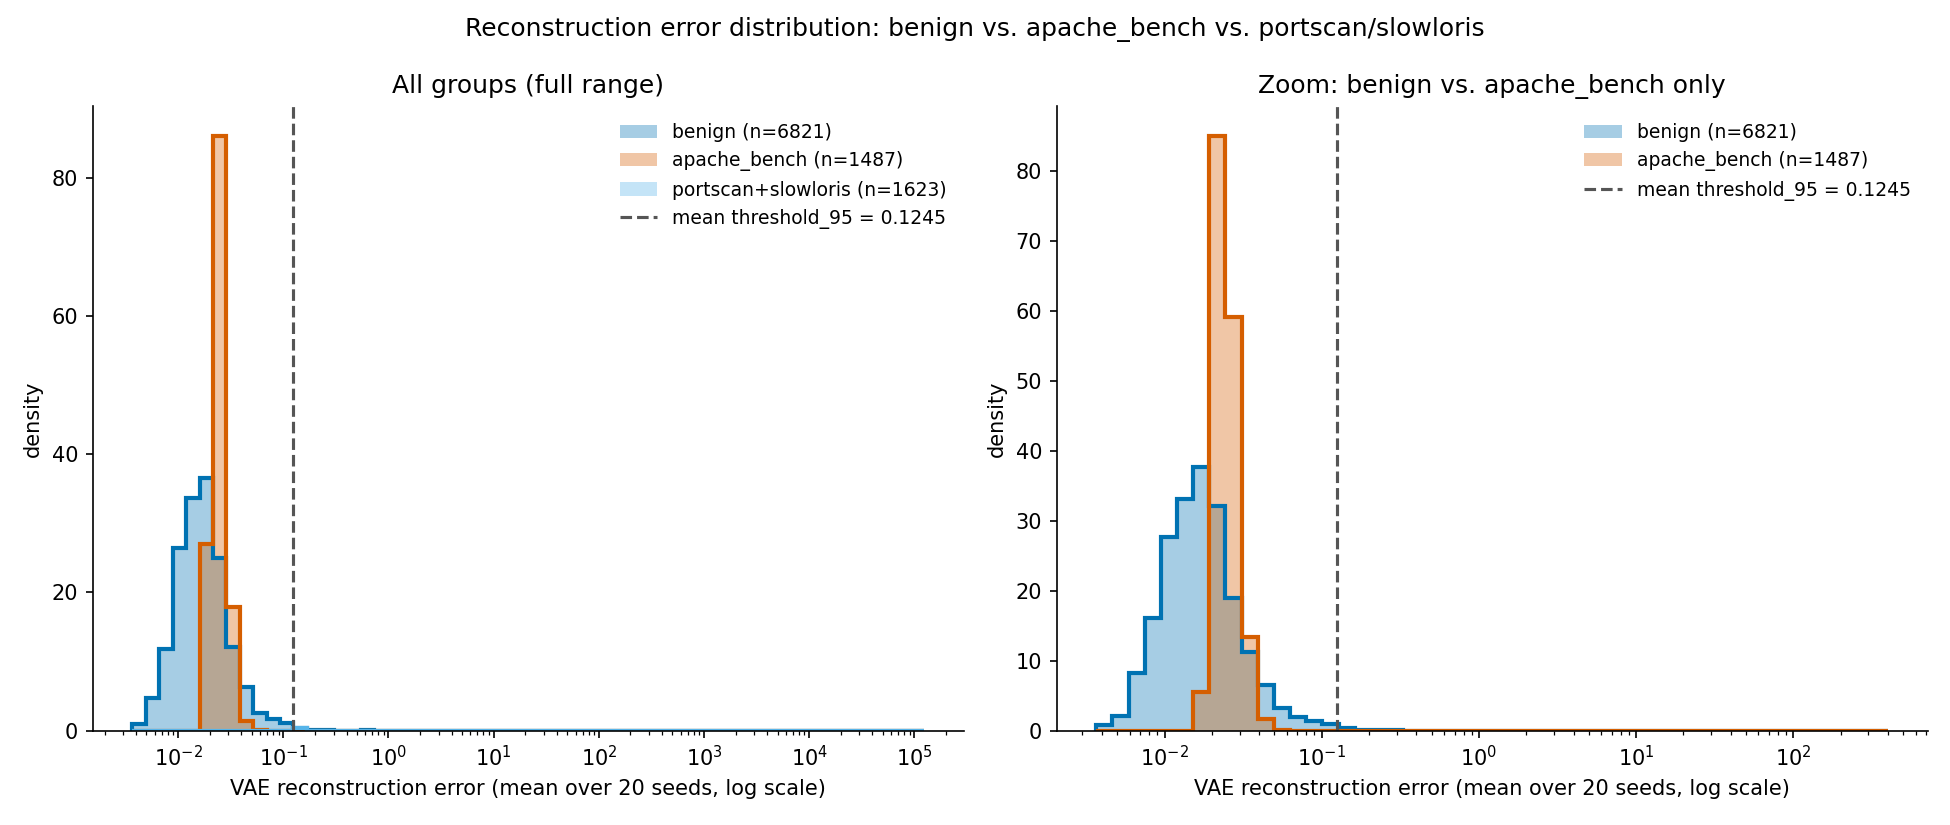

In [6]:
print("Published (20-seed) reconstruction error summary:")
display(pd.read_csv(os.path.join(DIAG_DIR, "vae_reconstruction_error_summary.csv")))
ipy_display(Image(filename=os.path.join(DIAG_DIR, "vae_reconstruction_error_hist.png")))

## 3. Temporal hypothesis test: inter-arrival time

Calls `temporal.consecutive_iat()` directly (the same function `test_apache_bench_temporal_hypothesis.py` uses) to reproduce the IAT computation and the ~2364x median-gap finding live.

**This is a statistical separability check only.** It has not been validated by adding an IAT/rate feature to the VAE and retraining — no retrain was run here or in the source script. Whether such a feature would actually push apache_bench's reconstruction error above threshold remains untested.

benign IAT: n=6812, median=2.18s
apache_bench IAT: n=1481, median=0.000922s
median ratio (benign / apache_bench): 2364x
KS statistic=0.7097, p-value=1.744e-321


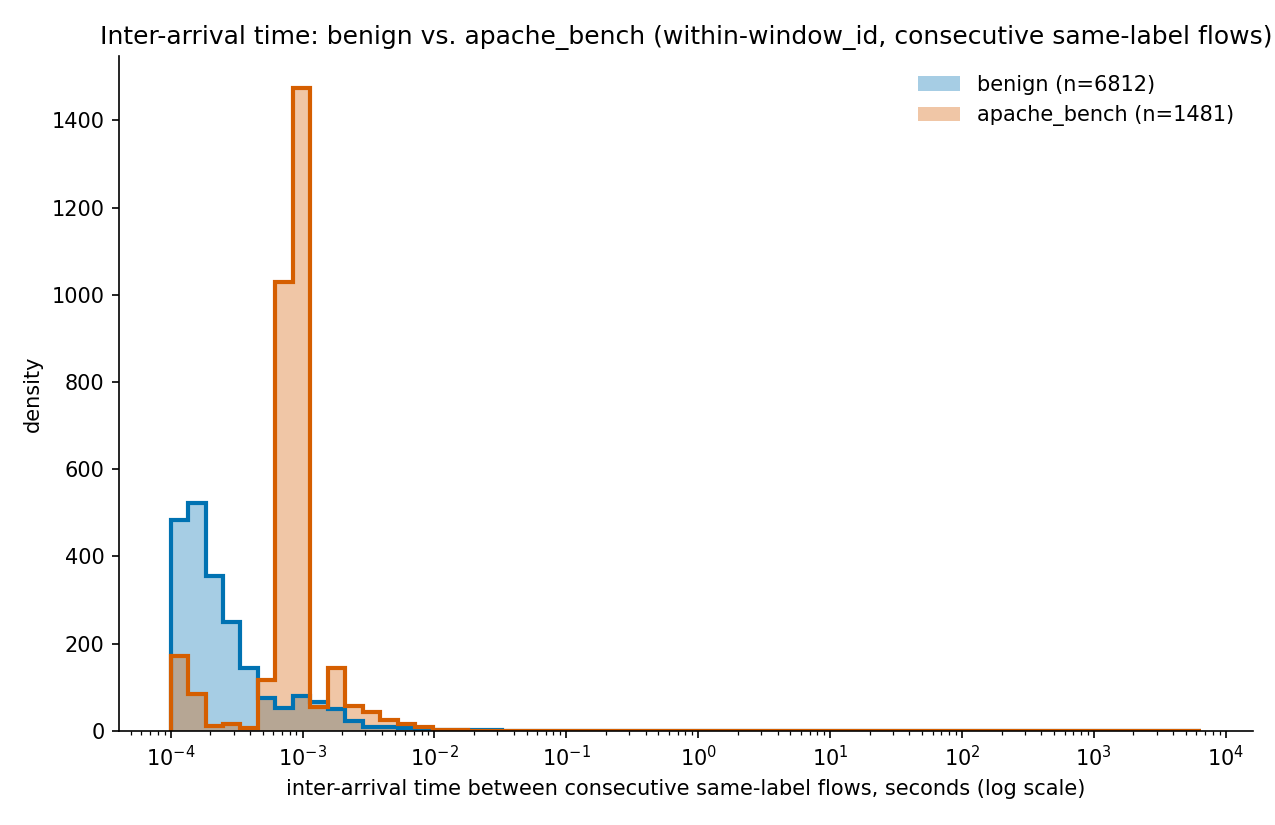

In [7]:
benign_iat = temporal.consecutive_iat(df, df["is_attack"] == 0)
apache_iat = temporal.consecutive_iat(df, df["attack_type"] == "apache_bench")
ks_stat, ks_pvalue = ks_2samp(benign_iat, apache_iat)

print(f"benign IAT: n={len(benign_iat)}, median={np.median(benign_iat):.4g}s")
print(f"apache_bench IAT: n={len(apache_iat)}, median={np.median(apache_iat):.4g}s")
print(f"median ratio (benign / apache_bench): {np.median(benign_iat)/np.median(apache_iat):.0f}x")
print(f"KS statistic={ks_stat:.4f}, p-value={ks_pvalue:.3e}")

_tmp_iat_path = os.path.join(DIAG_DIR, "_notebook_tmp_iat.png")
temporal.plot_iat_histogram(benign_iat, apache_iat, _tmp_iat_path)
ipy_display(Image(filename=_tmp_iat_path))
os.remove(_tmp_iat_path)

In [8]:
print("Published temporal_iat_summary.csv:")
display(pd.read_csv(os.path.join(DIAG_DIR, "temporal_iat_summary.csv")))
print()
print("NOTE (from diagnose_apache_bench_findings.md section 6): IAT's KS statistic is comparable to, not higher "
      "than, section 1's strongest single-flow features -- the meaningful difference is effect size (~3 orders "
      "of magnitude vs. a sub-1-sigma shift). This supports the temporal-feature hypothesis but does NOT confirm "
      "it would fix VAE detection -- that requires an actual retrain-and-evaluate pass, out of scope here.")

Published temporal_iat_summary.csv:


,group,n,mean,std,p5,p25,p50,p75,p95,p99,ks_statistic,ks_pvalue
0,benign,6812,10.430777,90.061974,0.000173,0.004726,2.179581,8.040339,33.918512,81.541582,0.709691,1.744052e-321
1,apache_bench,1481,24.305874,291.459516,0.000667,0.000839,0.000922,0.001683,0.006738,999.580855,0.709691,1.744052e-321



NOTE (from diagnose_apache_bench_findings.md section 6): IAT's KS statistic is comparable to, not higher than, section 1's strongest single-flow features -- the meaningful difference is effect size (~3 orders of magnitude vs. a sub-1-sigma shift). This supports the temporal-feature hypothesis but does NOT confirm it would fix VAE detection -- that requires an actual retrain-and-evaluate pass, out of scope here.
